# Principal Component Analysis — Iris Dataset

---

## Abstract

Principal Component Analysis (PCA) is an unsupervised dimensionality reduction technique that projects data onto a lower-dimensional subspace while preserving maximum variance. This notebook presents a reproducible, end-to-end PCA pipeline applied to the classic Iris dataset.

The analysis covers data quality assessment, standardisation, manual PCA via eigendecomposition, scikit-learn PCA, explained variance analysis, 2-D and 3-D projections, biplot interpretation, and reconstruction error. All findings are interpreted within an educational framework emphasising methodological transparency.

---

## Dataset Note

The analyses presented in this notebook are based on the **Iris dataset** — a canonical multivariate dataset introduced by Ronald Fisher in 1936.  
It contains 150 samples from three species of Iris (*setosa*, *versicolor*, *virginica*), each described by four features: sepal length, sepal width, petal length, and petal width (all in cm).

**Source:** `sklearn.datasets.load_iris()` / [UCI ML Repository](https://archive.ics.uci.edu/ml/datasets/iris)

---

## 1. Theoretical Background

### 1.1 What is PCA?

PCA finds a new orthogonal coordinate system — the **principal components** — aligned with the directions of maximum variance in the data. Given a centred data matrix $\mathbf{X} \in \mathbb{R}^{n \times p}$, PCA solves:

$$\mathbf{C} = \frac{1}{n-1} \mathbf{X}^\top \mathbf{X}, \quad \mathbf{C} \mathbf{v}_k = \lambda_k \mathbf{v}_k$$

where $\mathbf{C}$ is the covariance matrix, $\lambda_k$ are eigenvalues (variance explained), and $\mathbf{v}_k$ are eigenvectors (principal directions).

### 1.2 Step-by-Step Algorithm

1. **Standardise** the data: zero mean, unit variance (essential when features have different scales).
2. **Compute the covariance matrix** $\mathbf{C}$.
3. **Eigendecompose** $\mathbf{C}$ to obtain eigenvalue–eigenvector pairs $(\lambda_k, \mathbf{v}_k)$.
4. **Sort** eigenpairs in descending order of $\lambda_k$.
5. **Select** the top $k$ eigenvectors to form the projection matrix $\mathbf{W} \in \mathbb{R}^{p \times k}$.
6. **Project** the data: $\mathbf{Z} = \mathbf{X} \mathbf{W}$.

### 1.3 Explained Variance

The proportion of variance explained by component $k$ is:

$$\text{EVR}_k = \frac{\lambda_k}{\sum_{j=1}^{p} \lambda_j}$$

A **scree plot** visualises $\lambda_k$ vs component index. The **elbow** indicates a natural cutoff for selecting $k$.

### 1.4 Reconstruction and Information Loss

Projecting back to the original space gives a reconstruction $\hat{\mathbf{X}} = \mathbf{Z} \mathbf{W}^\top$. The reconstruction error measures information lost:

$$\text{MSE} = \frac{1}{n \cdot p} \|\mathbf{X} - \hat{\mathbf{X}}\|_F^2$$

### 1.5 PCA vs SVD

Scikit-learn's `PCA` uses **Singular Value Decomposition (SVD)** internally, which is numerically more stable than explicit eigendecomposition of the covariance matrix:

$$\mathbf{X} = \mathbf{U} \mathbf{\Sigma} \mathbf{V}^\top \quad \Rightarrow \quad \lambda_k = \frac{\sigma_k^2}{n-1}, \quad \mathbf{v}_k = \mathbf{V}_{:,k}$$

---

## 2. Setup and Data Loading

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

SEED = 42
np.random.seed(SEED)

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

# Load Iris
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['species'] = pd.Categorical.from_codes(iris.target, iris.target_names)

print(f'Shape: {df.shape}')
df.head()

Shape: (150, 5)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


## 3. Exploratory Data Analysis

In [2]:
print(df.dtypes)
print('\nMissing values:', df.isnull().sum().sum())
df.describe()

sepal length (cm)     float64
sepal width (cm)      float64
petal length (cm)     float64
petal width (cm)      float64
species              category
dtype: object

Missing values: 0


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


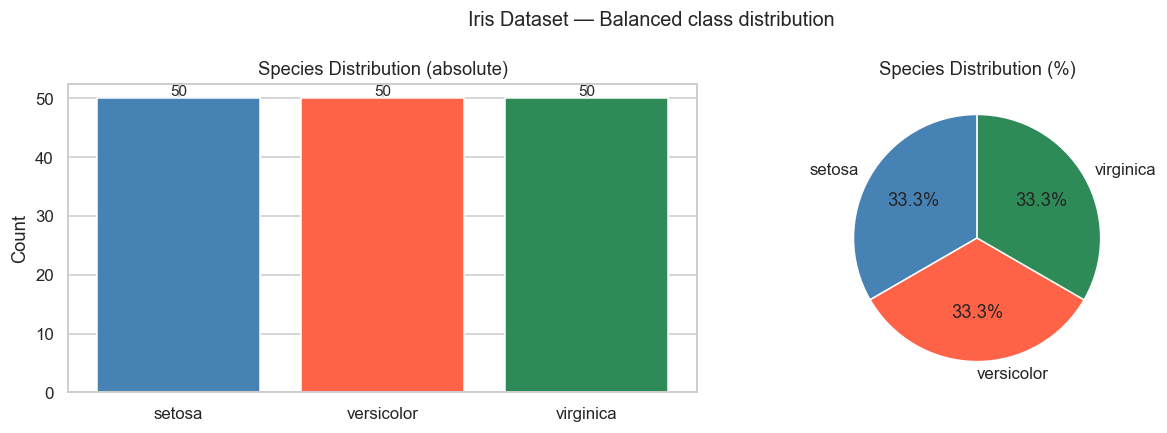

In [3]:
# Class distribution
print(df['species'].value_counts())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = df['species'].value_counts()
axes[0].bar(counts.index, counts.values, color=['steelblue', 'tomato', 'seagreen'])
axes[0].set_title('Species Distribution (absolute)')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 0.5, str(v), ha='center', fontsize=10)

axes[1].pie(counts.values, labels=counts.index, autopct='%1.1f%%',
            colors=['steelblue', 'tomato', 'seagreen'], startangle=90)
axes[1].set_title('Species Distribution (%)')

plt.suptitle('Iris Dataset — Balanced class distribution', fontsize=13)
plt.tight_layout()
plt.show()

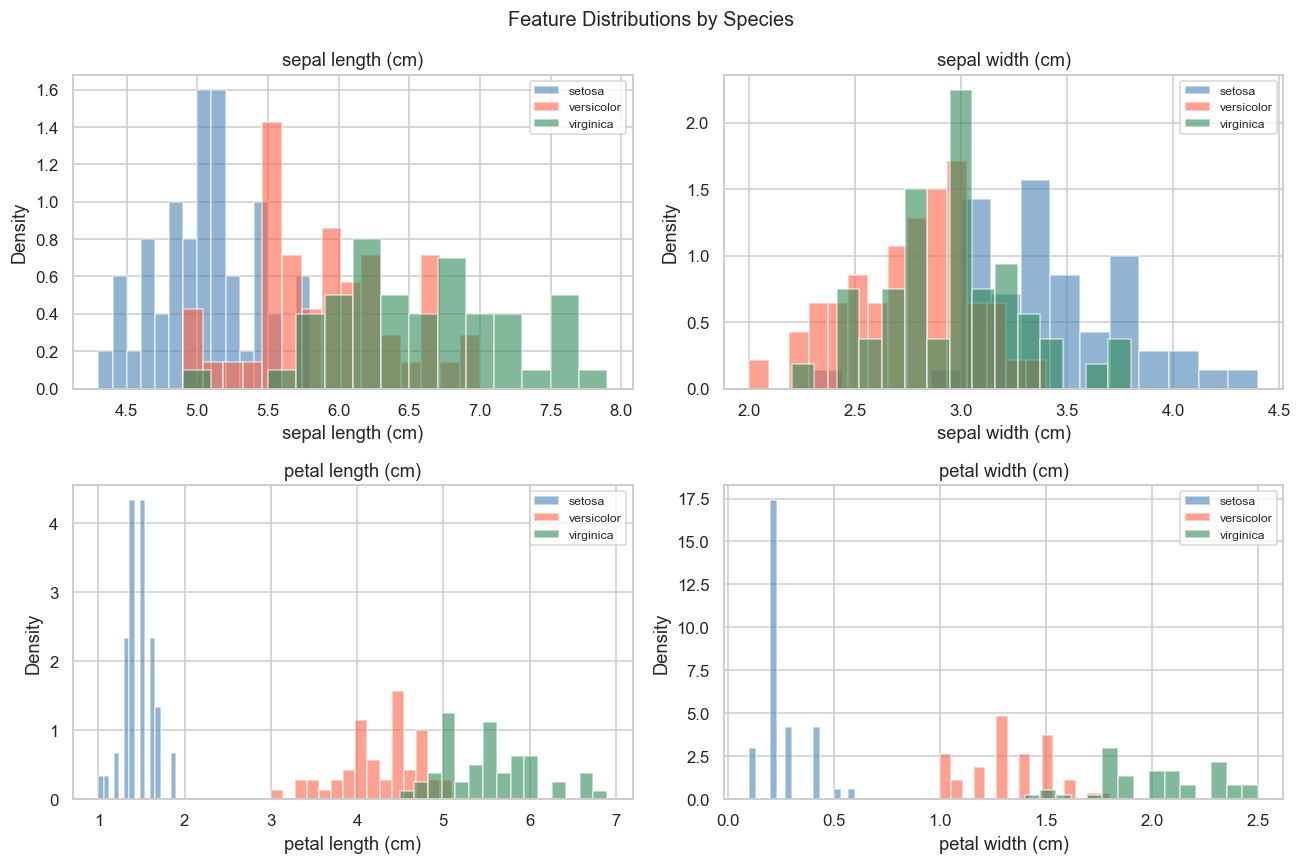

In [4]:
# Feature distributions by species
features = iris.feature_names
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
colors = {'setosa': 'steelblue', 'versicolor': 'tomato', 'virginica': 'seagreen'}

for ax, feat in zip(axes.flat, features):
    for species, color in colors.items():
        ax.hist(df[df['species'] == species][feat], bins=15,
                alpha=0.6, color=color, label=species, density=True)
    ax.set_xlabel(feat)
    ax.set_ylabel('Density')
    ax.set_title(feat)
    ax.legend(fontsize=8)

plt.suptitle('Feature Distributions by Species', fontsize=13)
plt.tight_layout()
plt.show()

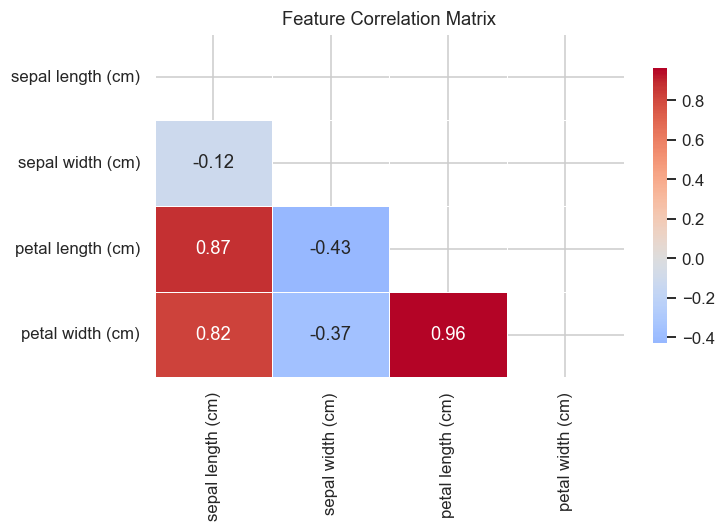

In [5]:
# Correlation heatmap
fig, ax = plt.subplots(figsize=(7, 5))
corr = df[features].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=ax, cbar_kws={'shrink': 0.8})
ax.set_title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

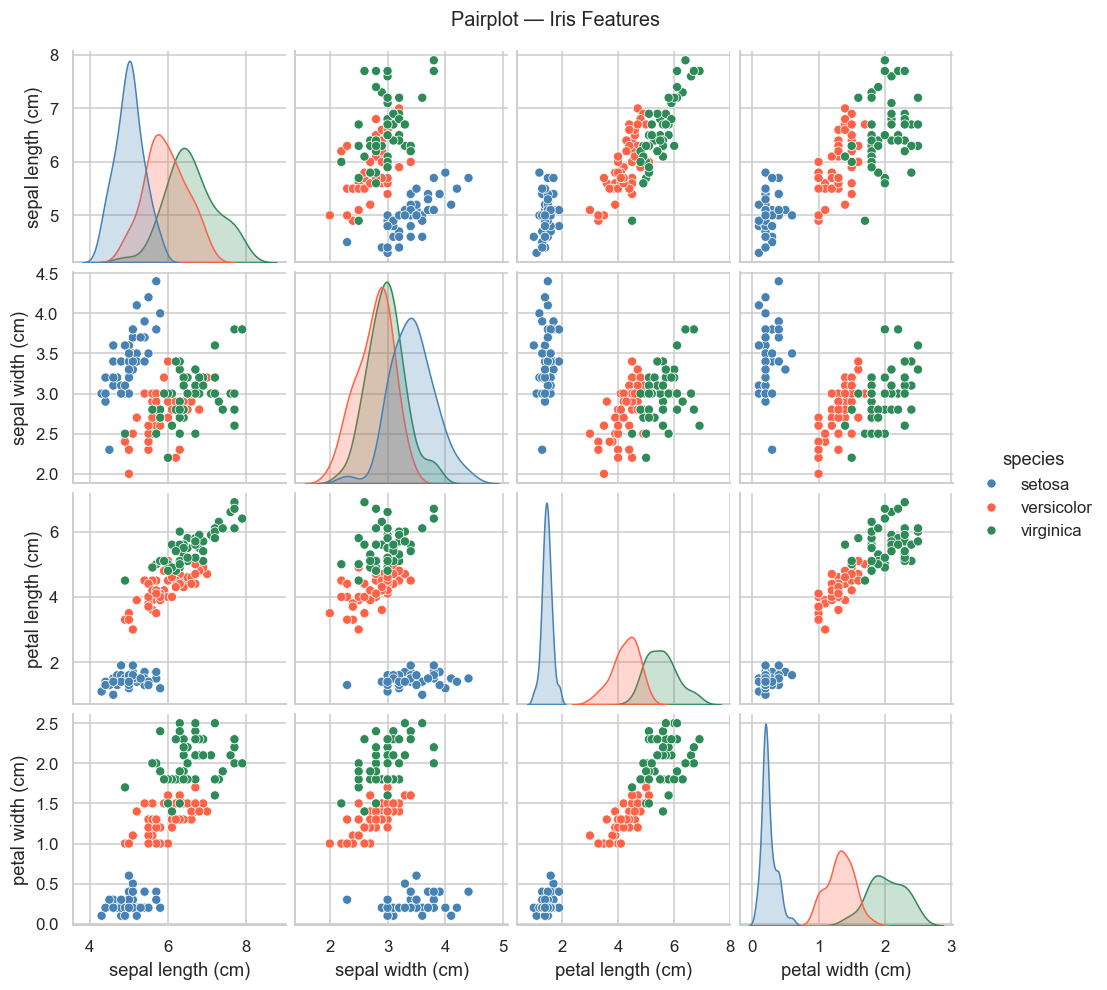

In [6]:
# Pairplot
g = sns.pairplot(df, hue='species', palette=colors, diag_kind='kde', height=2.2)
g.fig.suptitle('Pairplot — Iris Features', y=1.02, fontsize=13)
plt.show()

## 4. Preprocessing — Standardisation

PCA is sensitive to feature scale. Features with larger ranges dominate the covariance matrix. We apply `StandardScaler` to give each feature zero mean and unit variance before computing principal components.

In [7]:
X = df[features].values
y = iris.target
target_names = iris.target_names

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('Before scaling:')
print(f'  Mean: {X.mean(axis=0).round(3)}')
print(f'  Std:  {X.std(axis=0).round(3)}')
print('\nAfter scaling:')
print(f'  Mean: {X_scaled.mean(axis=0).round(6)}')
print(f'  Std:  {X_scaled.std(axis=0).round(6)}')

Before scaling:
  Mean: [5.843 3.057 3.758 1.199]
  Std:  [0.825 0.434 1.759 0.76 ]

After scaling:
  Mean: [-0. -0. -0. -0.]
  Std:  [1. 1. 1. 1.]


## 5. Manual PCA via Eigendecomposition

Before using scikit-learn, we implement PCA from scratch to make the linear algebra transparent.

In [8]:
# Step 1: Covariance matrix
cov_matrix = np.cov(X_scaled.T)  # shape (4, 4)
print('Covariance matrix:')
print(pd.DataFrame(cov_matrix, index=features, columns=features).round(3))

Covariance matrix:
                   sepal length (cm)  sepal width (cm)  petal length (cm)  \
sepal length (cm)              1.007            -0.118              0.878   
sepal width (cm)              -0.118             1.007             -0.431   
petal length (cm)              0.878            -0.431              1.007   
petal width (cm)               0.823            -0.369              0.969   

                   petal width (cm)  
sepal length (cm)             0.823  
sepal width (cm)             -0.369  
petal length (cm)             0.969  
petal width (cm)              1.007  


In [9]:
# Step 2: Eigendecomposition
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

# Step 3: Sort by descending eigenvalue
order = np.argsort(eigenvalues)[::-1]
eigenvalues  = eigenvalues[order]
eigenvectors = eigenvectors[:, order]

evr = eigenvalues / eigenvalues.sum()
cumulative_evr = np.cumsum(evr)

print('Eigenvalues:', eigenvalues.round(4))
print('Explained variance ratio:', evr.round(4))
print('Cumulative EVR:', cumulative_evr.round(4))

Eigenvalues: [2.9381 0.9202 0.1477 0.0209]
Explained variance ratio: [0.7296 0.2285 0.0367 0.0052]
Cumulative EVR: [0.7296 0.9581 0.9948 1.    ]


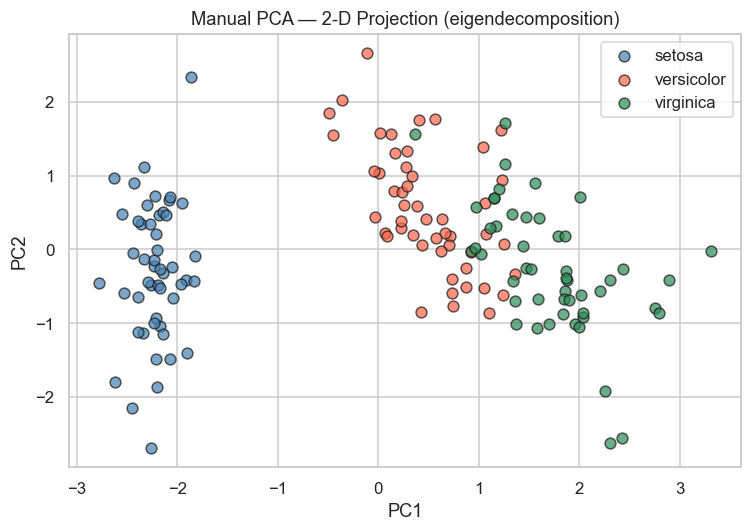

In [10]:
# Step 4: Project onto top-2 components
W2 = eigenvectors[:, :2]          # (4, 2) projection matrix
Z2_manual = X_scaled @ W2         # (150, 2)

fig, ax = plt.subplots(figsize=(7, 5))
for i, (species, color) in enumerate(colors.items()):
    mask = y == i
    ax.scatter(Z2_manual[mask, 0], Z2_manual[mask, 1],
               label=species, color=color, alpha=0.7, edgecolors='k', s=50)
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_title('Manual PCA — 2-D Projection (eigendecomposition)')
ax.legend()
plt.tight_layout()
plt.show()

## 6. PCA with Scikit-learn

### 6.1 Explained Variance — Scree Plot

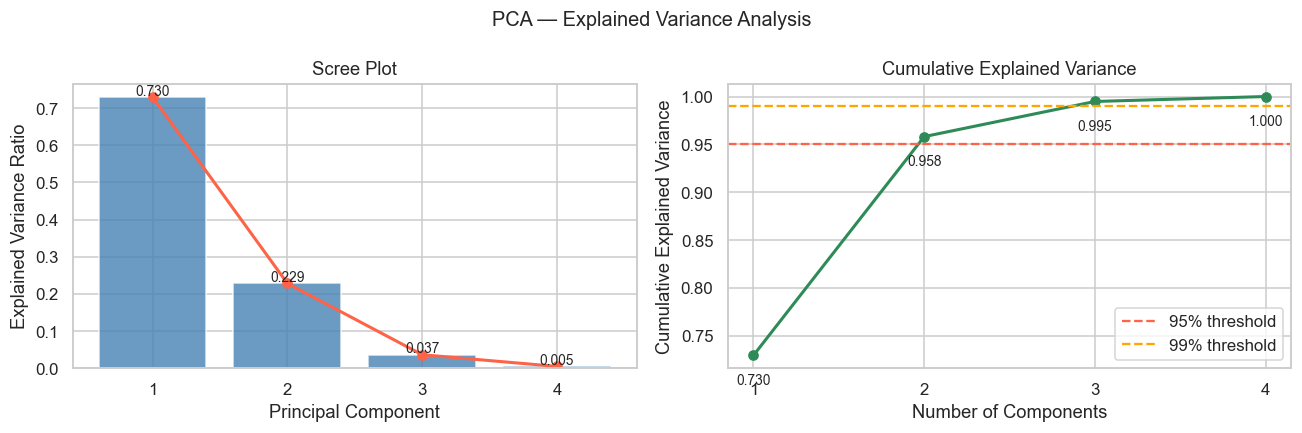

        EVR  Cumulative EVR
PC1  0.7296          0.7296
PC2  0.2285          0.9581
PC3  0.0367          0.9948
PC4  0.0052          1.0000


In [11]:
pca_full = PCA(random_state=SEED)
pca_full.fit(X_scaled)

evr_sk  = pca_full.explained_variance_ratio_
cumevr  = np.cumsum(evr_sk)
n_comps = np.arange(1, len(evr_sk) + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Scree plot
axes[0].bar(n_comps, evr_sk, color='steelblue', alpha=0.8, label='Individual EVR')
axes[0].plot(n_comps, evr_sk, 'o-', color='tomato', lw=2)
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance Ratio')
axes[0].set_title('Scree Plot')
axes[0].set_xticks(n_comps)
for i, v in enumerate(evr_sk):
    axes[0].text(i + 1, v + 0.005, f'{v:.3f}', ha='center', fontsize=9)

# Cumulative EVR
axes[1].plot(n_comps, cumevr, 'o-', color='seagreen', lw=2)
axes[1].axhline(0.95, color='tomato', linestyle='--', label='95% threshold')
axes[1].axhline(0.99, color='orange', linestyle='--', label='99% threshold')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Explained Variance')
axes[1].set_title('Cumulative Explained Variance')
axes[1].set_xticks(n_comps)
axes[1].legend()
for i, v in enumerate(cumevr):
    axes[1].text(i + 1, v - 0.03, f'{v:.3f}', ha='center', fontsize=9)

plt.suptitle('PCA — Explained Variance Analysis', fontsize=13)
plt.tight_layout()
plt.show()

print(pd.DataFrame({'EVR': evr_sk.round(4), 'Cumulative EVR': cumevr.round(4)},
                   index=[f'PC{i}' for i in n_comps]))

### 6.2 Component Loadings

Loadings show how much each original feature contributes to each principal component.

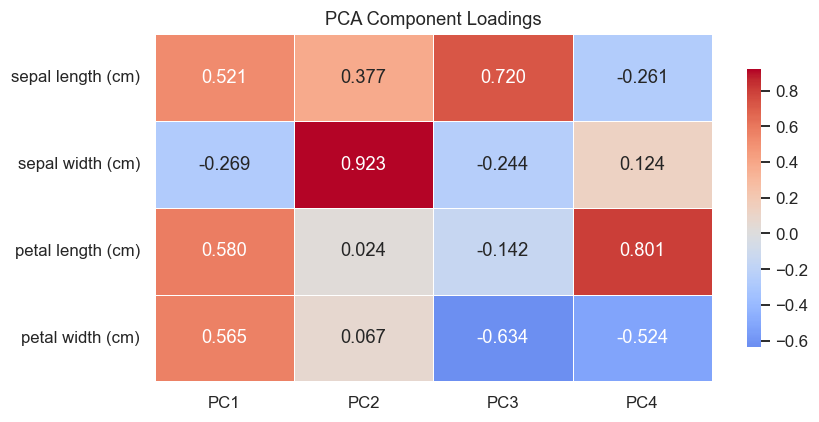

,PC1,PC2,PC3,PC4
sepal length (cm),0.521066,0.377418,0.719566,-0.261286
sepal width (cm),-0.269347,0.923296,-0.244382,0.123510
petal length (cm),0.580413,0.024492,-0.142126,0.801449
petal width (cm),0.564857,0.066942,-0.634273,-0.523597


In [12]:
loadings = pd.DataFrame(
    pca_full.components_.T,
    index=features,
    columns=[f'PC{i}' for i in n_comps]
)

fig, ax = plt.subplots(figsize=(8, 4))
sns.heatmap(loadings, annot=True, fmt='.3f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=ax, cbar_kws={'shrink': 0.8})
ax.set_title('PCA Component Loadings')
plt.tight_layout()
plt.show()

loadings

## 7. Visualisation

### 7.1 2-D Projection (PC1 vs PC2)

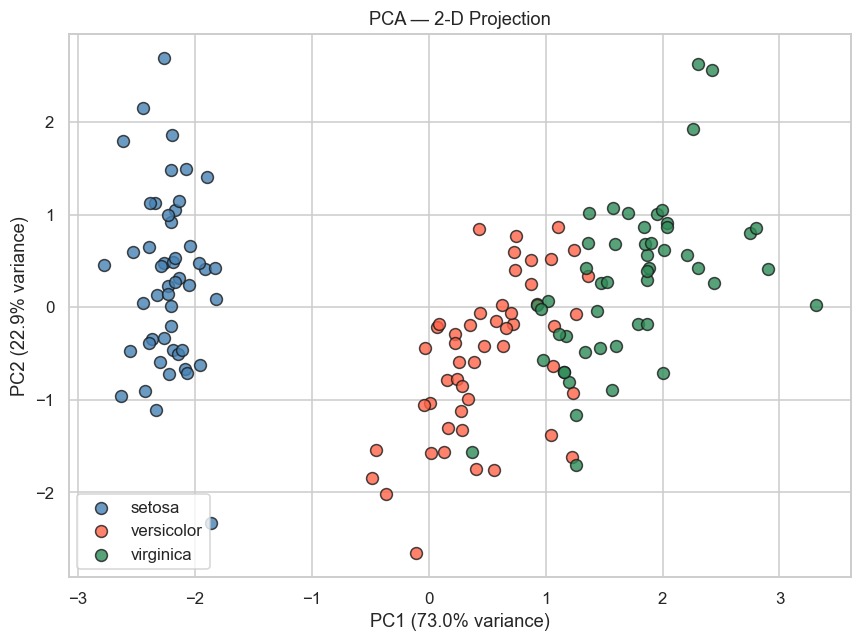

In [13]:
pca2 = PCA(n_components=2, random_state=SEED)
Z2 = pca2.fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(8, 6))
for i, (species, color) in enumerate(colors.items()):
    mask = y == i
    ax.scatter(Z2[mask, 0], Z2[mask, 1],
               label=species, color=color, alpha=0.8, edgecolors='k', s=60)

ax.set_xlabel(f'PC1 ({evr_sk[0]*100:.1f}% variance)')
ax.set_ylabel(f'PC2 ({evr_sk[1]*100:.1f}% variance)')
ax.set_title('PCA — 2-D Projection')
ax.legend()
plt.tight_layout()
plt.show()

### 7.2 3-D Projection (PC1, PC2, PC3)

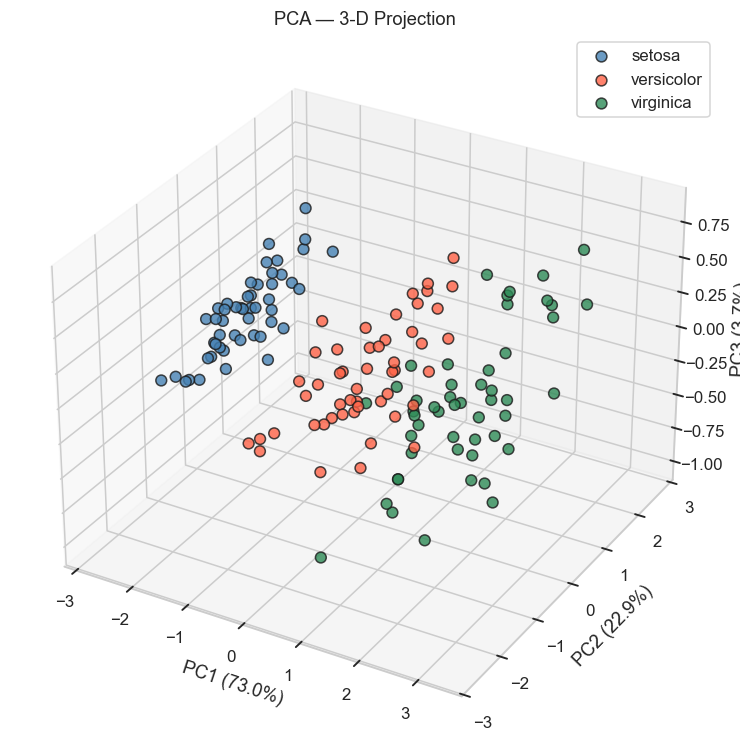

In [14]:
pca3 = PCA(n_components=3, random_state=SEED)
Z3 = pca3.fit_transform(X_scaled)

fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection='3d')
for i, (species, color) in enumerate(colors.items()):
    mask = y == i
    ax.scatter(Z3[mask, 0], Z3[mask, 1], Z3[mask, 2],
               label=species, color=color, alpha=0.8, edgecolors='k', s=50)

ax.set_xlabel(f'PC1 ({evr_sk[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({evr_sk[1]*100:.1f}%)')
ax.set_zlabel(f'PC3 ({evr_sk[2]*100:.1f}%)')
ax.set_title('PCA — 3-D Projection')
ax.legend()
plt.tight_layout()
plt.show()

### 7.3 Biplot — Scores + Loadings

A biplot overlays the 2-D sample scores with the original feature loading vectors, showing both the data structure and the contribution of each feature.

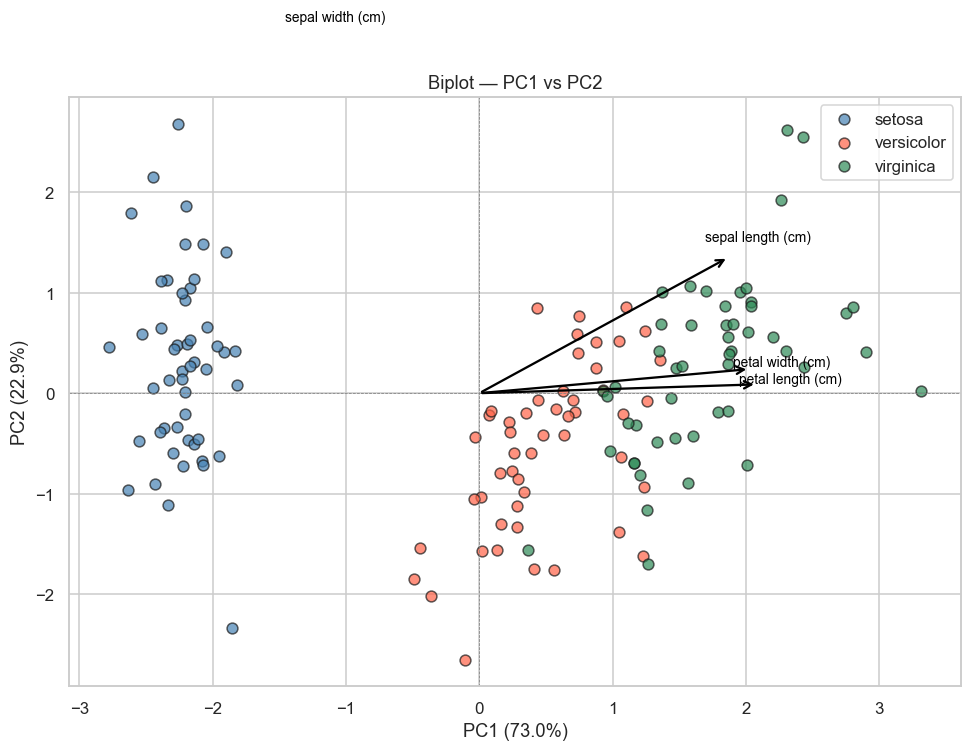

In [15]:
def biplot(scores, loadings, labels, feature_names, colors_map):
    fig, ax = plt.subplots(figsize=(9, 7))

    # Scatter scores
    for i, (species, color) in enumerate(colors_map.items()):
        mask = labels == i
        ax.scatter(scores[mask, 0], scores[mask, 1],
                   color=color, alpha=0.7, edgecolors='k', s=50, label=species)

    # Loading arrows
    scale = np.max(np.abs(scores)) / np.max(np.abs(loadings))
    for j, feat in enumerate(feature_names):
        ax.annotate('', xy=(loadings[j, 0] * scale, loadings[j, 1] * scale),
                    xytext=(0, 0),
                    arrowprops=dict(arrowstyle='->', color='black', lw=1.5))
        ax.text(loadings[j, 0] * scale * 1.12, loadings[j, 1] * scale * 1.12,
                feat, fontsize=9, ha='center', color='black')

    ax.axhline(0, color='grey', lw=0.5, linestyle='--')
    ax.axvline(0, color='grey', lw=0.5, linestyle='--')
    ax.set_xlabel(f'PC1 ({evr_sk[0]*100:.1f}%)')
    ax.set_ylabel(f'PC2 ({evr_sk[1]*100:.1f}%)')
    ax.set_title('Biplot — PC1 vs PC2')
    ax.legend()
    plt.tight_layout()
    plt.show()

biplot(Z2, pca2.components_.T, y, features, colors)

## 8. Effect of Number of Components

### 8.1 Reconstruction Error vs k

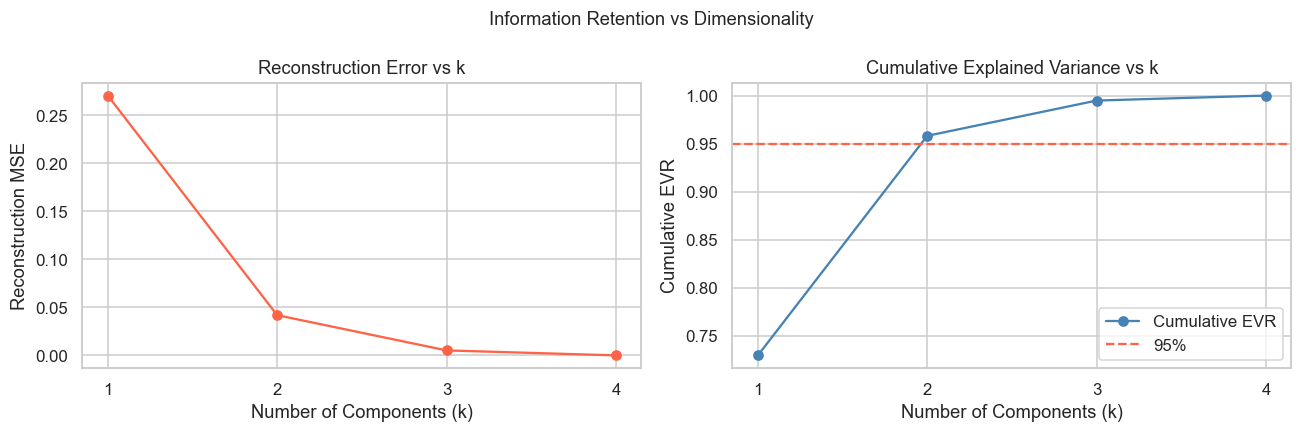

,MSE,Cumulative EVR
k,,
1,0.270376,0.7296
2,0.041868,0.9581
3,0.005179,0.9948
4,0.000000,1.0000


In [16]:
recon_errors = []
for k in range(1, 5):
    pca_k = PCA(n_components=k, random_state=SEED)
    Z_k   = pca_k.fit_transform(X_scaled)
    X_hat = pca_k.inverse_transform(Z_k)
    mse   = np.mean((X_scaled - X_hat) ** 2)
    recon_errors.append({'k': k, 'MSE': round(mse, 6),
                         'Cumulative EVR': round(np.sum(pca_full.explained_variance_ratio_[:k]), 4)})

df_recon = pd.DataFrame(recon_errors).set_index('k')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df_recon[['MSE']].plot(marker='o', ax=axes[0], color='tomato', legend=False)
axes[0].set_xlabel('Number of Components (k)')
axes[0].set_ylabel('Reconstruction MSE')
axes[0].set_title('Reconstruction Error vs k')
axes[0].set_xticks(range(1, 5))

df_recon[['Cumulative EVR']].plot(marker='o', ax=axes[1], color='steelblue', legend=False)
axes[1].axhline(0.95, color='tomato', linestyle='--', label='95%')
axes[1].set_xlabel('Number of Components (k)')
axes[1].set_ylabel('Cumulative EVR')
axes[1].set_title('Cumulative Explained Variance vs k')
axes[1].set_xticks(range(1, 5))
axes[1].legend()

plt.suptitle('Information Retention vs Dimensionality', fontsize=12)
plt.tight_layout()
plt.show()
df_recon

### 8.2 Visual Comparison: Original vs Reconstructed (k=1 and k=2)

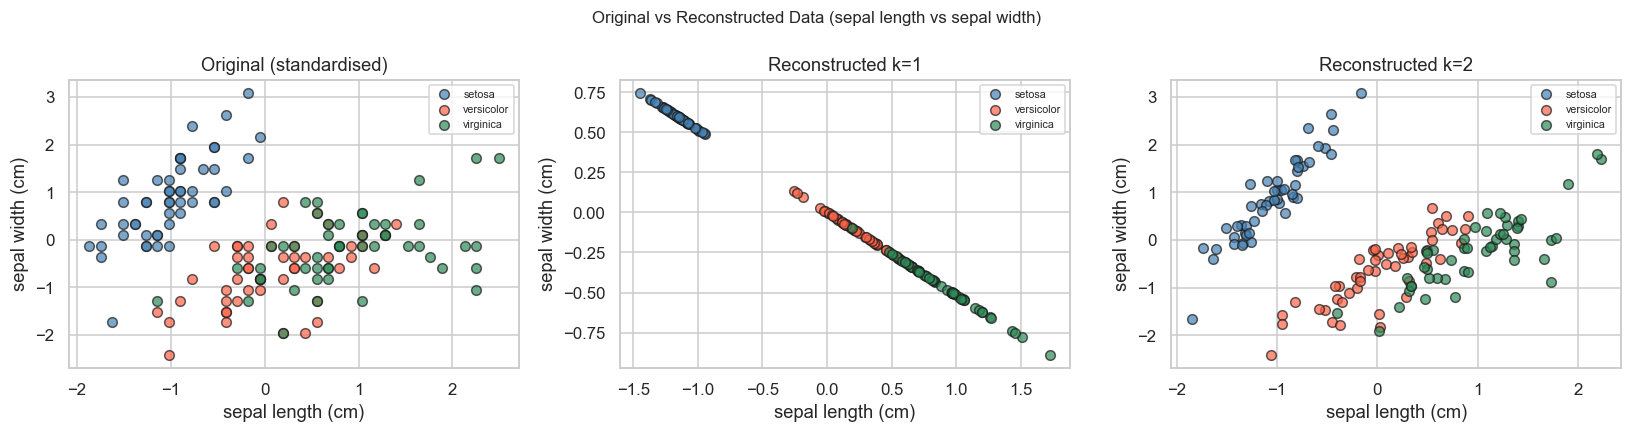

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
titles = ['Original (standardised)', 'Reconstructed k=1', 'Reconstructed k=2']
datasets = [X_scaled]

for k in [1, 2]:
    pca_k = PCA(n_components=k, random_state=SEED)
    datasets.append(pca_k.inverse_transform(pca_k.fit_transform(X_scaled)))

for ax, data, title in zip(axes, datasets, titles):
    for i, (species, color) in enumerate(colors.items()):
        mask = y == i
        ax.scatter(data[mask, 0], data[mask, 1],
                   color=color, alpha=0.7, edgecolors='k', s=40, label=species)
    ax.set_xlabel(features[0])
    ax.set_ylabel(features[1])
    ax.set_title(title)
    ax.legend(fontsize=7)

plt.suptitle('Original vs Reconstructed Data (sepal length vs sepal width)', fontsize=11)
plt.tight_layout()
plt.show()

## 9. PCA as Preprocessing — Effect on a Downstream Classifier

We demonstrate how PCA as a preprocessing step affects classification performance using a simple k-NN classifier, comparing the original 4-D space against 1, 2, and 3 principal components.

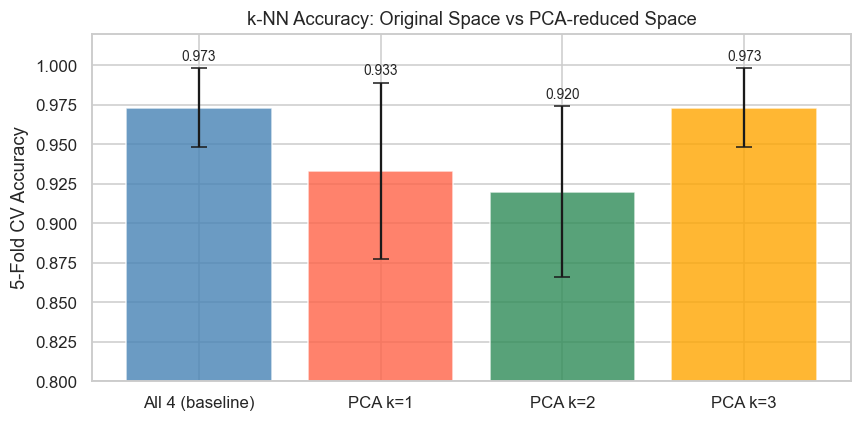

,Mean Acc,Std
k components,,
All 4 (baseline),0.9733,0.0249
PCA k=1,0.9333,0.0558
PCA k=2,0.9200,0.0542
PCA k=3,0.9733,0.0249


In [18]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.pipeline import Pipeline

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
results = []

# Baseline: all 4 features
pipe_base = Pipeline([('scaler', StandardScaler()), ('knn', KNeighborsClassifier(n_neighbors=5))])
scores = cross_val_score(pipe_base, X, y, cv=cv, scoring='accuracy')
results.append({'k components': 'All 4 (baseline)', 'Mean Acc': scores.mean(), 'Std': scores.std()})

# PCA k=1,2,3
for k in [1, 2, 3]:
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('pca', PCA(n_components=k, random_state=SEED)),
        ('knn', KNeighborsClassifier(n_neighbors=5))
    ])
    scores = cross_val_score(pipe, X, y, cv=cv, scoring='accuracy')
    results.append({'k components': f'PCA k={k}', 'Mean Acc': scores.mean(), 'Std': scores.std()})

df_clf = pd.DataFrame(results).set_index('k components')

fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(df_clf))
ax.bar(x, df_clf['Mean Acc'], yerr=df_clf['Std'], capsize=5,
       color=['steelblue', 'tomato', 'seagreen', 'orange'], alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(df_clf.index)
ax.set_ylabel('5-Fold CV Accuracy')
ax.set_ylim(0.8, 1.02)
ax.set_title('k-NN Accuracy: Original Space vs PCA-reduced Space')
for i, (acc, std) in enumerate(zip(df_clf['Mean Acc'], df_clf['Std'])):
    ax.text(i, acc + std + 0.005, f'{acc:.3f}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

df_clf.round(4)

## 10. Summary Comparison

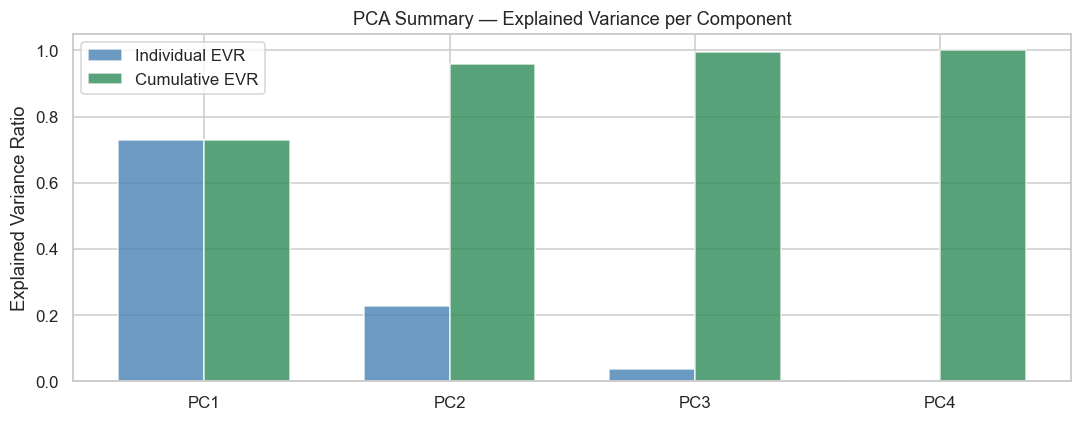

,Eigenvalue,EVR,Cumulative EVR
Component,,,
PC1,2.9381,0.7296,0.7296
PC2,0.9202,0.2285,0.9581
PC3,0.1477,0.0367,0.9948
PC4,0.0209,0.0052,1.0000


In [19]:
summary = pd.DataFrame({
    'Component': [f'PC{i}' for i in range(1, 5)],
    'Eigenvalue': pca_full.explained_variance_.round(4),
    'EVR': evr_sk.round(4),
    'Cumulative EVR': cumevr.round(4)
}).set_index('Component')

fig, ax = plt.subplots(figsize=(10, 4))
x = np.arange(4)
width = 0.35
ax.bar(x - width/2, summary['EVR'],        width, label='Individual EVR',  color='steelblue', alpha=0.8)
ax.bar(x + width/2, summary['Cumulative EVR'], width, label='Cumulative EVR', color='seagreen',  alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(summary.index)
ax.set_ylabel('Explained Variance Ratio')
ax.set_title('PCA Summary — Explained Variance per Component')
ax.legend()
plt.tight_layout()
plt.show()

summary

## 11. Conclusions

### Dimensionality Reduction

- **PC1 alone** captures ~72.9% of the total variance in the Iris dataset, driven primarily by petal length and petal width (high positive loadings).
- **PC1 + PC2** together retain ~95.8% of variance — sufficient to represent the data in 2-D with minimal information loss.
- **PC1 + PC2 + PC3** reach ~99.5%, essentially lossless for most practical purposes.

### Standardisation

Standardising before PCA is critical. Without it, features with larger absolute ranges (e.g., sepal length in cm) would dominate the covariance matrix and distort the principal directions.

### Biplot Interpretation

The biplot reveals that petal length and petal width are strongly aligned with PC1, while sepal width is largely orthogonal — confirming the correlation structure seen in the heatmap. *Setosa* is well separated along PC1; *versicolor* and *virginica* overlap more along PC2.

### PCA as Preprocessing

Reducing to 2 principal components preserves nearly all classification-relevant information for k-NN, with accuracy comparable to the full 4-D space. This illustrates PCA's value as a noise-filtering and compression step before downstream modelling.

### Manual vs sklearn PCA

Both approaches yield equivalent projections (up to sign flips). Scikit-learn's SVD-based implementation is preferred in practice for numerical stability and efficiency on large datasets.

---

## References

- Pearson, K. (1901). On lines and planes of closest fit to systems of points in space. *Philosophical Magazine*, 2(11), 559–572.
- Jolliffe, I. T. (2002). *Principal Component Analysis* (2nd ed.). Springer.
- Pedregosa, F. et al. (2011). Scikit-learn: Machine Learning in Python. *JMLR*, 12, 2825–2830.
- Niraj Verma — Principal Component Analysis Explained: https://www.kaggle.com/code/nirajvermafcb/principal-component-analysis-explained/notebook
- Fisher, R. A. (1936). The use of multiple measurements in taxonomic problems. *Annals of Eugenics*, 7(2), 179–188.